In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Вспомогательные функции

def hardlim(n):
    return (n >= 0).astype(float)

def predict(X, W, b):
    return hardlim(W @ X + b.reshape(-1, 1))

def mae(x):
    return np.mean(np.abs(x))

def rosenblatt_train(X, y, W, b, epochs=50, lr=0.5):
    n_samples = X.shape[1]
    for ep in range(epochs):
        for j in range(n_samples):
            xi = X[:, j : j + 1]
            yi = y[:, j : j + 1]
            y_pred = hardlim(W @ xi + b.reshape(-1, 1))
            error = yi - y_pred
            if mae(error) != 0:
                W = W + lr * (error @ xi.T)
                b = b + lr * error.flatten()
        if mae(y - predict(X, W, b)) == 0:
            break
    return W, b

## 1. Бинарная классификация (2 класса, 6 точек)
### 1.1 Обучающее множество

In [3]:
X_train = np.array([[2.7, -3.8, -0.4, -1.7, 2.9, 0.2],
                    [4.3,  0.6, -4.9, -3.4, -1.9, -3.4]])
y_train = np.array([[0.0, 0.0, 1.0, 1.0, 1.0, 1.0]])

print("X_train:", X_train)
print("y_train:", y_train)

X_train: [[ 2.7 -3.8 -0.4 -1.7  2.9  0.2]
 [ 4.3  0.6 -4.9 -3.4 -1.9 -3.4]]
y_train: [[0. 0. 1. 1. 1. 1.]]


### 1.2 Создание сети
Однонейронный персептрон с 2 входами (x1, x2), пороговой функцией активации hardlim и ненулевым смещением (bias). Нейрон имеет 2 весовых коэффициента и 1 смещение.

### 1.3 Ручное обучение по правилу Розенблатта (2 эпохи)
#### 1.3.1 Инициализация случайными значениями

In [4]:
np.random.seed(12)
W1 = np.random.uniform(-1, 1, (1, 2))
b1 = np.random.uniform(-1, 1, 1)

print("W начальные:", W1)
print("b начальное:", b1)

W начальные: [[-0.69167432  0.48009939]]
b начальное: [-0.47336997]


#### 1.3.2 Расчёт двух эпох обучения

In [5]:
lr = 0.5
n_samples = X_train.shape[1]

for ep in range(1, 3):
    for j in range(n_samples):
        xi = X_train[:, j : j + 1]
        yi = y_train[:, j : j + 1]
        y_pred = hardlim(W1 @ xi + b1.reshape(-1, 1))
        error = yi - y_pred
        if mae(error) != 0:
            W1 = W1 + lr * (error @ xi.T)
            b1 = b1 + lr * error.flatten()
    y_out = predict(X_train, W1, b1)
    print(f"Эпоха {ep}: W={W1}, b={b1}, MAE={mae(y_train - y_out):.4f}")

Эпоха 1: W=[[ 1.00832568 -2.26990061]], b=[-0.47336997], MAE=0.0000
Эпоха 2: W=[[ 1.00832568 -2.26990061]], b=[-0.47336997], MAE=0.0000


#### 1.3.3 Визуализация после ручного обучения

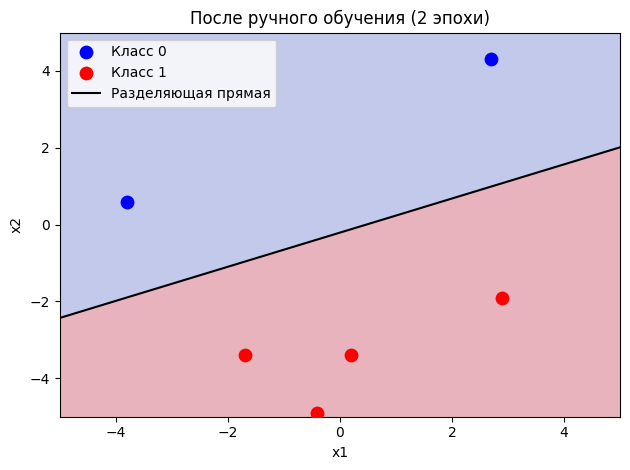

In [6]:
x1_range = np.linspace(-5, 5, 200)
x2_line = -(W1[0, 0] * x1_range + b1[0]) / W1[0, 1]

xx1, xx2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid_points = np.vstack([xx1.ravel(), xx2.ravel()])
grid_classes = predict(grid_points, W1, b1).reshape(xx1.shape)

fig, ax = plt.subplots()
ax.pcolormesh(xx1, xx2, grid_classes, alpha=0.3, cmap="coolwarm")
colors = {0.0: "blue", 1.0: "red"}
labels = {0.0: "Класс 0", 1.0: "Класс 1"}
plotted = set()
for i in range(X_train.shape[1]):
    cls = y_train[0, i]
    label = labels[cls] if cls not in plotted else None
    ax.scatter(X_train[0, i], X_train[1, i], color=colors[cls], label=label, s=80, zorder=3)
    plotted.add(cls)
ax.plot(x1_range, x2_line, "k-", label="Разделяющая прямая")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("После ручного обучения (2 эпохи)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Автоматическое обучение (50 эпох)
#### 1.4.1–1.4.2 Инициализация и обучение

In [7]:
np.random.seed(15)
W1 = np.random.uniform(-1, 1, (1, 2))
b1 = np.random.uniform(-1, 1, 1)

W1, b1 = rosenblatt_train(X_train, y_train, W1, b1, epochs=50, lr=0.5)

y_out = predict(X_train, W1, b1)
print("W финальные:", W1)
print("b финальное:", b1)
print(f"MAE на обучающей выборке: {mae(y_train - y_out):.4f}")

W финальные: [[ 0.69763539 -0.64220815]]
b финальное: [-0.89127357]
MAE на обучающей выборке: 0.0000


#### 1.4.3 Проверка качества — 3 случайные точки

Точка 1: x1=-2.515, x2=-2.397 -> класс 0
Точка 2: x1=-0.500, x2=3.704 -> класс 0
Точка 3: x1=-0.891, x2=-3.150 -> класс 1


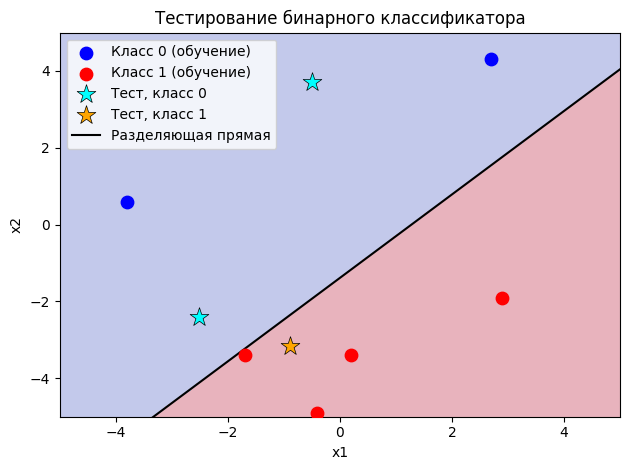

In [8]:
np.random.seed(33)
X_test = np.random.uniform(-5, 5, (2, 3))
y_test = predict(X_test, W1, b1)

for i in range(3):
    print(f"Точка {i+1}: x1={X_test[0,i]:.3f}, x2={X_test[1,i]:.3f} -> класс {int(y_test[0,i])}")

xx1, xx2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid_points = np.vstack([xx1.ravel(), xx2.ravel()])
grid_classes = predict(grid_points, W1, b1).reshape(xx1.shape)

x1_range = np.linspace(-5, 5, 200)
x2_line = -(W1[0, 0] * x1_range + b1[0]) / W1[0, 1]

fig, ax = plt.subplots()
ax.pcolormesh(xx1, xx2, grid_classes, alpha=0.3, cmap="coolwarm")

colors_train = {0.0: "blue", 1.0: "red"}
labels_train = {0.0: "Класс 0 (обучение)", 1.0: "Класс 1 (обучение)"}
plotted = set()
for i in range(X_train.shape[1]):
    cls = y_train[0, i]
    label = labels_train[cls] if cls not in plotted else None
    ax.scatter(X_train[0, i], X_train[1, i], color=colors_train[cls], label=label, s=80, zorder=3)
    plotted.add(cls)

colors_test = {0.0: "cyan", 1.0: "orange"}
labels_test = {0.0: "Тест, класс 0", 1.0: "Тест, класс 1"}
plotted_test = set()
for i in range(X_test.shape[1]):
    cls = y_test[0, i]
    label = labels_test[cls] if cls not in plotted_test else None
    ax.scatter(X_test[0, i], X_test[1, i], color=colors_test[cls], marker="*",
                s=200, zorder=4, edgecolors="black", linewidths=0.5, label=label)
    plotted_test.add(cls)

ax.plot(x1_range, x2_line, "k-", label="Разделяющая прямая")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Тестирование бинарного классификатора")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Линейно неразделимый случай

X_mod: [[ 2.7 -3.8 -0.4 -1.7  2.9  0.2 -1. ]
 [ 4.3  0.6 -4.9 -3.4 -1.9 -3.4 -3. ]]
y_mod: [[0. 0. 1. 1. 1. 1. 0.]]
W финальные: [[ 0.7762616  -2.60457254]]
b финальное: [-6.71693854]
MAE на модифицированной выборке: 0.1429


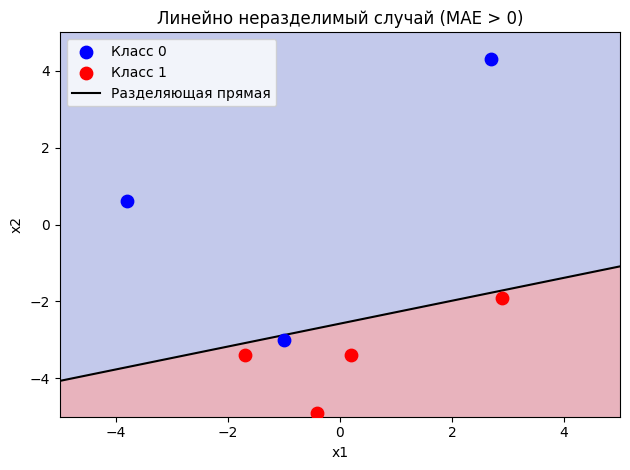

In [9]:
# Добавляем точку (-1.0, -3.0) класса 0 в область класса 1 — нарушаем линейную разделимость
X_mod = np.hstack([X_train, np.array([[-1.0], [-3.0]])])
y_mod = np.hstack([y_train, np.array([[0.0]])])

print("X_mod:", X_mod)
print("y_mod:", y_mod)

np.random.seed(20)
W_mod = np.random.uniform(-1, 1, (1, 2))
b_mod = np.random.uniform(-1, 1, 1)

W_mod, b_mod = rosenblatt_train(X_mod, y_mod, W_mod, b_mod, epochs=50, lr=0.5)

y_out_mod = predict(X_mod, W_mod, b_mod)
print("W финальные:", W_mod)
print("b финальное:", b_mod)
print(f"MAE на модифицированной выборке: {mae(y_mod - y_out_mod):.4f}")

x1_range = np.linspace(-5, 5, 200)
x2_line_mod = -(W_mod[0, 0] * x1_range + b_mod[0]) / W_mod[0, 1]

xx1, xx2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid_points = np.vstack([xx1.ravel(), xx2.ravel()])
grid_classes_mod = predict(grid_points, W_mod, b_mod).reshape(xx1.shape)

fig, ax = plt.subplots()
ax.pcolormesh(xx1, xx2, grid_classes_mod, alpha=0.3, cmap="coolwarm")

colors_cls = {0.0: "blue", 1.0: "red"}
labels_cls = {0.0: "Класс 0", 1.0: "Класс 1"}
plotted = set()
for i in range(X_mod.shape[1]):
    cls = y_mod[0, i]
    label = labels_cls[cls] if cls not in plotted else None
    ax.scatter(X_mod[0, i], X_mod[1, i], color=colors_cls[cls], label=label, s=80, zorder=3)
    plotted.add(cls)

ax.plot(x1_range, x2_line_mod, "k-", label="Разделяющая прямая")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Линейно неразделимый случай (MAE > 0)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Классификация на 4 класса (2 нейрона)
### 3.1 Обучающее множество

In [16]:
X_train2 = np.array([[0.6, 2.4, 1.4, -3.7, -1.4, 2.8, -3.7, 0.5],
                        [-2.4, 0, -2, -0.3, 2.8, 1.6, -4.8, -2]])
y_train2 = np.array([[1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0],
                        [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]])

print("X_train2:", X_train2)
print("y_train2:", y_train2)

print("\n=== Структура сети ===")
print(f"Количество входов: 2")
print(f"Количество нейронов: 2")
print(f"Функция активации: hardlim")
print(f"Смещение (bias): да")

X_train2: [[ 0.6  2.4  1.4 -3.7 -1.4  2.8 -3.7  0.5]
 [-2.4  0.  -2.  -0.3  2.8  1.6 -4.8 -2. ]]
y_train2: [[1. 1. 1. 0. 0. 1. 1. 1.]
 [0. 1. 0. 0. 1. 1. 0. 0.]]

=== Структура сети ===
Количество входов: 2
Количество нейронов: 2
Функция активации: hardlim
Смещение (bias): да


### 3.2–3.4 Инициализация и обучение

In [17]:
best_mae = 1.0
best_W, best_b = None, None

max_attempts = 100
for attempt in range(max_attempts):
    np.random.seed(attempt)
    W2 = np.random.uniform(-1, 1, (2, 2))
    b2 = np.random.uniform(-1, 1, 2)
    W2, b2 = rosenblatt_train(X_train2, y_train2, W2, b2, epochs=50, lr=0.5)
    y_out2 = predict(X_train2, W2, b2)
    current_mae = mae(y_train2 - y_out2)
    if current_mae < best_mae:
        best_mae = current_mae
        best_W, best_b = W2.copy(), b2.copy()
    if current_mae == 0:
        print(f"Сошлось за попытку {attempt + 1} (seed={attempt})")
        break

W2, b2, final_mae = best_W, best_b, best_mae

if final_mae != 0:
    print(f"Не удалось достичь MAE=0 за {max_attempts} попыток.")

print("W2 финальные:", W2)
print("b2 финальные:", b2)
print(f"MAE на обучающей выборке: {final_mae:.4f}")

Сошлось за попытку 1 (seed=0)
W2 финальные: [[ 0.39762701 -0.76962127]
 [ 1.10552675  1.28976637]]
b2 финальные: [0.3473096  0.29178823]
MAE на обучающей выборке: 0.0000


### 3.5 Проверка качества — 5 случайных точек

Точка 1: x1=-4.069, x2=-2.145 -> метка [1, 0]
Точка 2: x1=4.717, x2=3.626 -> метка [0, 1]
Точка 3: x1=-0.161, x2=-4.589 -> метка [1, 0]
Точка 4: x1=-2.575, x2=-3.917 -> метка [1, 0]
Точка 5: x1=0.311, x2=2.672 -> метка [0, 1]


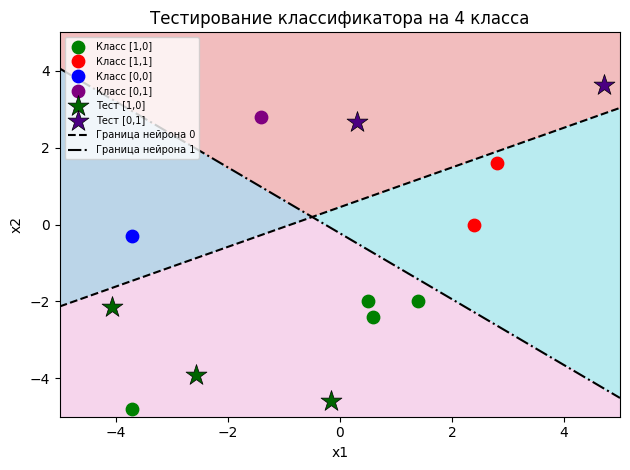

In [18]:
np.random.seed(55)
X_test2 = np.random.uniform(-5, 5, (2, 5))
y_test2 = predict(X_test2, W2, b2)

for i in range(5):
    print(f"Точка {i+1}: x1={X_test2[0,i]:.3f}, x2={X_test2[1,i]:.3f} -> метка [{int(y_test2[0,i])}, {int(y_test2[1,i])}]")

xx1, xx2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid_points = np.vstack([xx1.ravel(), xx2.ravel()])
grid_out = predict(grid_points, W2, b2)
grid_label = (grid_out[0] * 2 + grid_out[1]).reshape(xx1.shape)

fig, ax = plt.subplots()
ax.pcolormesh(xx1, xx2, grid_label, alpha=0.3, cmap="tab10", vmin=0, vmax=3)

class_colors = {(1, 1): "red", (0, 0): "blue", (1, 0): "green", (0, 1): "purple"}
class_labels = {(1, 1): "Класс [1,1]", (0, 0): "Класс [0,0]",
                (1, 0): "Класс [1,0]", (0, 1): "Класс [0,1]"}
plotted_train = set()
for i in range(X_train2.shape[1]):
    cls = (int(y_train2[0, i]), int(y_train2[1, i]))
    label = class_labels[cls] if cls not in plotted_train else None
    ax.scatter(X_train2[0, i], X_train2[1, i], color=class_colors[cls], s=80, zorder=3, label=label)
    plotted_train.add(cls)

test_colors = {(1, 1): "darkred", (0, 0): "darkblue", (1, 0): "darkgreen", (0, 1): "indigo"}
test_labels = {(1, 1): "Тест [1,1]", (0, 0): "Тест [0,0]",
               (1, 0): "Тест [1,0]", (0, 1): "Тест [0,1]"}
plotted_test = set()
for i in range(X_test2.shape[1]):
    cls = (int(y_test2[0, i]), int(y_test2[1, i]))
    label = test_labels[cls] if cls not in plotted_test else None
    ax.scatter(X_test2[0, i], X_test2[1, i], color=test_colors[cls], marker="*",
               s=250, zorder=4, edgecolors="black", linewidths=0.5, label=label)
    plotted_test.add(cls)

x1_range = np.linspace(-5, 5, 200)
for i, (ls, lbl) in enumerate([("k--", "Граница нейрона 0"), ("k-.", "Граница нейрона 1")]):
    if abs(W2[i, 1]) > 1e-9:
        x2_line = -(W2[i, 0] * x1_range + b2[i]) / W2[i, 1]
        ax.plot(x1_range, x2_line, ls, label=lbl)

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Тестирование классификатора на 4 класса")
ax.legend(loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()